In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import shutil
import yaml
from hashlib import sha1
import uuid

from pftnc.config import AppConfig, DatasetArtifact
from datetime import datetime
from tqdm.auto import tqdm
import json

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [2]:
def read_registry(regsitry_path):

    if regsitry_path.exists():

        data = yaml.safe_load(regsitry_path.read_text())

        if data is None:
            data = {"datasets": {}}

        return data

    else:

        return {"datasets": {}}


def validate_registry(base_path, registry):

    base_key = str(base_path)

    disk_versions = {
        p.name for p in base_path.iterdir()
        if p.is_dir()
    } if base_path.exists() else set()

    yaml_versions = set(
        registry.get("datasets", {})
        .get(base_key, {})
        .keys()
    )

    if disk_versions != yaml_versions:

        raise RuntimeError(
            "Dataset registry mismatch\n"
            f"Dataset: {base_key}\n"
            f"Disk versions: {sorted(disk_versions)}\n"
            f"Registry versions: {sorted(yaml_versions)}"
        )


def generate_dataset_version(cfg, sites) -> str:
    sites = "_".join(sites)
    timestamp = datetime.now().strftime("%Y%m%dT%H%M%SZ%z")

    # stable hash of config - if multiple users created the dataset using same configurations
    cfg_dict = cfg.model_dump(mode="json")
    cfg_json = json.dumps(cfg_dict, sort_keys=True)
    cfg_hash = sha1(cfg_json.encode()).hexdigest()[:8]

    # randomness prevents collisions
    rand = uuid.uuid4().hex[:6]

    return f"{sites}_{timestamp}_{cfg_hash}_{rand}"


def register_dataset_version(registry_path, base_path, description, version):

    registry = read_registry(registry_path)

    base_path = str(base_path)

    if "datasets" not in registry:
        registry["datasets"] = {}

    if base_path not in registry["datasets"]:
        registry["datasets"][base_path] = {}

    registry["datasets"][base_path][version] = {

        "path": "/".join([base_path, version]),
        "description": description,
        "created": datetime.utcnow().isoformat()

    }

    registry_path.parent.mkdir(parents=True, exist_ok=True)

    with registry_path.open("w") as f:
        yaml.safe_dump(registry, f, sort_keys=False)


def save_feature_schema(df, path):

    schema = {

        "columns": list(df.columns),
        "n_features": len(df.columns)

    }

    with open(path / "feature_schema.yaml", "w") as f:
        yaml.safe_dump(schema, f)

In [3]:
def log_fractions_transform(y_df, targets, denominator, epsilon):
    """
    Transform PFT concentrations to (total_ug_per_l, log-fraction per non-denominator PFT).

    Produces:
      total_ug_per_l            — sum of all targets
      log_fractions_<t>         — log((t + ε) / (total + ε)) for every non-denominator target

    The denominator PFT is not given its own output column; it is recovered as
    the residual (total − sum of predicted PFTs) during back-transformation.
    Input concentrations are assumed non-negative (curated upstream).
    """
    numerators = [t for t in targets if t != denominator]
    total = y_df[targets].sum(axis=1)
    out = pd.DataFrame(index=y_df.index)
    out["total_ug_per_l"] = total
    for num in numerators:
        out[f"log_fractions_{num}"] = np.log((y_df[num] + epsilon) / (total + epsilon))
    return out

In [4]:

def _assert_valid_labels(y: pd.DataFrame, context: str) -> None:
    nan_counts = y.isna().sum()
    inf_counts = pd.Series(
        np.isinf(y.values).sum(axis=0), index=y.columns
    )
    if nan_counts.any() or inf_counts.any():
        raise ValueError(
            f"Label validation failed ({context}):\n"
            f"  NaN  : {nan_counts[nan_counts > 0].to_dict()}\n"
            f"  Inf  : {inf_counts[inf_counts > 0].to_dict()}"
        )


def generate_year_folds(cfg, df):
    base_path = cfg.feature_engineering.output_dataset.storage.base_path
    regsitry_path = cfg.feature_engineering.output_dataset.storage.registry_path
    
    registry = read_registry(regsitry_path)
    validate_registry(base_path, registry)
    version = generate_dataset_version(cfg, cfg.feature_engineering.output_dataset.metadata.sites)

    path = base_path / version
    path.mkdir(parents=True)

    try:
        target_cols = cfg.feature_engineering.output_dataset.metadata.dataset_schema.targets
        date_col = cfg.feature_engineering.output_dataset.metadata.dataset_schema.date_column
        final_test_year = cfg.feature_engineering.output_dataset.metadata.splits.final_test_year

        log_fractions_cfg = getattr(cfg.feature_engineering.features.log_fractions, "log_fractions", None)
        log_fractions_enabled = log_fractions_cfg is not None and log_fractions_cfg.enabled

        df = df.copy()

        check_target_quality(df, target_cols)

        df[date_col] = pd.to_datetime(df[date_col])
        df["__year__"] = df[date_col].dt.year

        years = sorted(df["__year__"].unique())
        if final_test_year not in years:
            raise ValueError("final_test_year not present in dataset")

        train_years = [y for y in years if y != final_test_year]
        folds = {}

        exclude_cols = set(target_cols) | {"__year__"}
        feature_cols = [c for c in df.columns if c not in exclude_cols]

        for i, val_year in enumerate(train_years):

            test_year = train_years[(i + 1) % len(train_years)]
            train = [y for y in train_years if y not in [val_year, test_year]]

            fold_name = f"fold_{val_year}"
            fold_dir = path / fold_name
            fold_dir.mkdir()

            train_df = df[df["__year__"].isin(train)]
            val_df = df[df["__year__"] == val_year]
            test_df = df[df["__year__"] == test_year]

            for split, split_df in {"train": train_df, "val": val_df, "test": test_df}.items():

                x = split_df[feature_cols]
                y = split_df[target_cols]

                if log_fractions_enabled:
                    y = log_fractions_transform(y, target_cols, log_fractions_cfg.denominator, log_fractions_cfg.epsilon)

                _assert_valid_labels(y, f"{fold_name}/{split}")

                x.to_parquet(fold_dir / f"{split}_X.parquet")
                y.to_parquet(fold_dir / f"{split}_y.parquet")

            folds[fold_name] = {
                "train_years": train,
                "val_year": val_year,
                "test_year": test_year,
            }

        def convert(obj):
            if isinstance(obj, (np.integer,)):
                return int(obj)
            if isinstance(obj, (np.floating,)):
                return float(obj)
            raise TypeError

        with open(path / "folds.json", "w") as f:
            json.dump(folds, f, indent=2, default=convert)

        final_test = df[df["__year__"] == final_test_year]
        final_dir = path / "final_test"
        final_dir.mkdir()

        x = final_test.drop(columns=target_cols)
        y = final_test[target_cols]

        if log_fractions_enabled:
            y = log_fractions_transform(y, target_cols, log_fractions_cfg.denominator, log_fractions_cfg.epsilon)

        _assert_valid_labels(y, "final_test")

        x.to_parquet(final_dir / "test_X.parquet")
        y.to_parquet(final_dir / "test_y.parquet")

        # Save metadata so the training notebook can back-transform predictions
        if log_fractions_enabled:
            numerators = [t for t in target_cols if t != log_fractions_cfg.denominator]
            log_fractions_target_cols = ["total_ug_per_l"] + [f"log_fractions_{n}" for n in numerators]
            log_fractions_meta = {
                "enabled": True,
                "epsilon": log_fractions_cfg.epsilon,
                "denominator": log_fractions_cfg.denominator,
                "original_targets": list(target_cols),
                "log_fractions_targets": log_fractions_target_cols,
            }
            with open(path / "log_fractions_meta.json", "w") as f:
                json.dump(log_fractions_meta, f, indent=2)

    except Exception:
        if path.exists():
            shutil.rmtree(path)
        raise

    register_dataset_version(regsitry_path, base_path, cfg.feature_engineering.output_dataset.storage.description, version)

    return version, folds

In [5]:
def read_input_dataset(cfg) -> pd.DataFrame:
    """
    Read the input dataset defined in:

        cfg.feature_engineering.input_dataset

    Supports:
    - direct path mode
    - registry-managed mode

    Assumes exactly one parquet file exists in the dataset directory.
    """

    storage = cfg.feature_engineering.input_dataset

    # Direct path mode
    if storage.path is not None:

        dataset_path = Path(storage.path)

    # Registry mode
    else:

        registry = read_registry(storage.registry_path)
        validate_registry(storage.base_path, registry)
        base_key = str(storage.base_path)
        datasets = registry.get("datasets", {})

        if base_key not in datasets:
            raise ValueError(
                f"Base dataset path not found in registry:\n"
                f"{base_key}"
            )

        versions = datasets[base_key]

        if storage.version not in versions:
            raise ValueError(
                f"Dataset version '{storage.version}' not found.\n"
                f"Available versions:\n"
                f"{list(versions.keys())}"
            )

        dataset_info = versions[storage.version]
        dataset_path = Path(dataset_info["path"])


    if not dataset_path.exists():
        raise FileNotFoundError(
            f"Dataset path does not exist:\n{dataset_path}"
        )

    parquet_files = list(dataset_path.glob("*.parquet"))

    if len(parquet_files) != 1:
        raise ValueError(
            f"Expected exactly one parquet file in:\n"
            f"{dataset_path}\n"
            f"Found: {len(parquet_files)}"
        )

    parquet_path = parquet_files[0]
    df = pd.read_parquet(parquet_path)

    print(f"Loaded dataset : {parquet_path}")
    print(f"Rows           : {len(df)}")
    print(f"Columns        : {len(df.columns)}")

    return df

In [6]:
def run_feature_engineering(cfg):

    df = read_input_dataset(cfg)

    rows_before = len(df)

    print("Filling missing dates with NaNs")
    df = fill_missing_dates(
        df=df,
        date_column=cfg.feature_engineering.output_dataset.metadata.dataset_schema.date_column,
    )

    schema = cfg.feature_engineering.output_dataset.metadata.dataset_schema

    group_col = schema.group_column
    date_col = schema.date_column

    columns = [
        c
        for sensor_cols in schema.sensors.values()
        for c in sensor_cols
    ]

    windows = cfg.feature_engineering.features.rolling.windows
    statistics = cfg.feature_engineering.features.rolling.statistics

    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values([group_col, date_col])

    def compute_slope(x):
        # Drop NaN values and keep their original positions as x-coordinates
        valid_mask = ~x.isna()
        y = x[valid_mask].values
        if len(y) < 2:
            return np.nan
        t = np.where(valid_mask)[0].astype(float)
        # Centre t for numerical stability, then use direct OLS dot-product formula.
        # β = Σ(t - t̄)(y) / Σ(t - t̄)²  — avoids SVD entirely.
        t -= t.mean()
        denom = np.dot(t, t)
        if denom == 0:
            return np.nan
        return np.dot(t, y) / denom

    all_stat_names = ["mean", "median", "max", "slope", "std", "count"]
    enabled_stats = [s for s in all_stat_names if s in statistics]
    total_tasks = len(columns) * len(windows) * len(enabled_stats)

    new_features: dict[str, pd.Series] = {}

    grouped = df.groupby(group_col)

    with tqdm(total=total_tasks, desc="Generating rolling features") as pbar:
        for col in columns:
            for w in windows:
                # v1.0 (this is v1.0, currently in use!)
                # introduce nans
                # run windows stats
                # remove all rows with NaNs in target cols

                # TODO:
                # v1.1 (we need to brainstorm a bit on this before we put this in use, p.s., is not implemented yet)
                # interpolate gaps less than 30 days
                # introduce nans for missing dates
                # run windows stats 
                # last step - apply mask from original insitu data + 60 days (if more than 30 days is missing)
                # nan problem only during the computation of features (rolling)
                # add nans -> compute features -> remove the rows where target is nan

                roll = grouped[col].rolling(window=w, min_periods=1)

                if "mean" in statistics:
                    new_features[f"{col}_mean_{w}"] = roll.mean().reset_index(level=0, drop=True)
                    pbar.update(1)

                if "median" in statistics:
                    new_features[f"{col}_median_{w}"] = roll.median().reset_index(level=0, drop=True)
                    pbar.update(1)

                if "max" in statistics:
                    new_features[f"{col}_max_{w}"] = roll.max().reset_index(level=0, drop=True)
                    pbar.update(1)

                if "slope" in statistics:
                    new_features[f"{col}_slope_{w}"] = (
                        roll.apply(compute_slope, raw=False).reset_index(level=0, drop=True)
                    )
                    pbar.update(1)

                if "std" in statistics:
                    new_features[f"{col}_std_{w}"] = roll.std().reset_index(level=0, drop=True)
                    pbar.update(1)

                if "count" in statistics:
                    # count of non-NaN values in window — proxy for data availability
                    new_features[f"{col}_count_{w}"] = roll.count().reset_index(level=0, drop=True)
                    pbar.update(1)

    # Days since last valid (non-NaN) observation per sensor.
    # For nowcasting, how stale the most recent satellite reading is matters.
    date_ser = df[date_col]
    for col in columns:
        is_valid = ~df[col].isna()
        last_valid_date = (
            date_ser.where(is_valid)
            .groupby(df[group_col])
            .transform(lambda s: s.ffill())
        )
        days_since = (date_ser - last_valid_date).dt.days
        new_features[f"{col}_days_since_obs"] = days_since

    # Cyclic day-of-year encoding (captures seasonal bloom dynamics)
    doy = df[date_col].dt.dayofyear
    new_features["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    new_features["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)

    features_df = pd.DataFrame(new_features)
    df = pd.concat([df, features_df], axis=1)

    # remove rows where all targets are NaN
    target_cols = cfg.feature_engineering.output_dataset.metadata.dataset_schema.targets
    df = df.dropna(subset=target_cols, how="all")

    rows_after = len(df)

    print(f"Total rows before filling missing dates:  {rows_before}")
    print(f"Total rows after feature generation and removing data that was added earlier:   {rows_after}")

    return df

In [7]:
def check_target_quality(df, target_cols):
    """
    Raise if any target column contains NaN or negative values.

    Call this on the prepared dataframe before build_dataset.
    Negative concentrations are physically invalid and cause NaN in the
    log-fractions transform; NaN targets have no valid label.
    """
    issues = {}
    nan_counts = df[target_cols].isna().sum()
    neg_counts = (df[target_cols] < 0).sum()
    if nan_counts.any():
        issues["nan"] = nan_counts[nan_counts > 0].to_dict()
    if neg_counts.any():
        issues["negative"] = neg_counts[neg_counts > 0].to_dict()
    if issues:
        raise ValueError(
            "Target quality check failed:\n"
            + "\n".join(f"  {k}: {v}" for k, v in issues.items())
            + "\nFix the data before calling build_dataset."
        )
    print(f"Target quality OK — {len(df)} rows, no NaN or negative values in targets.")


In [8]:
def fill_missing_dates(
    df: pd.DataFrame,
    date_column: str,
    freq: str = "D",
) -> pd.DataFrame:
    df = df.copy()
    df[date_column] = pd.to_datetime(df[date_column])

    full_range = pd.date_range(
        start=df[date_column].min(),
        end=df[date_column].max(),
        freq=freq,
    )

    return (
        df.set_index(date_column)
        .reindex(full_range)
        .rename_axis(date_column)
        .reset_index()
    )


In [9]:
def build_dataset(cfg):
    print("Running feature engineering")

    features_df = run_feature_engineering(cfg)
    
    print("Generating folds")
    version, folds = generate_year_folds(cfg, features_df)

    dataset_path = cfg.feature_engineering.output_dataset.storage.base_path / version

    save_feature_schema(features_df, dataset_path)

    # save config
    config_path = dataset_path / "config.yml"

    with open(config_path, "w") as f:
        yaml.safe_dump(
            cfg.model_dump(mode="json"),
            f,
            sort_keys=False,
        )
    # save metadata
    metadata_path = dataset_path / "metadata.yml"
    with open(metadata_path, "w") as f:
        yaml.safe_dump(
            cfg.feature_engineering.output_dataset.metadata.model_dump(mode="json"),
            f,
            sort_keys=False,
        )
            
    print(f"Dataset version {version} created at {dataset_path}")

    return DatasetArtifact(
        base_path=cfg.feature_engineering.output_dataset.storage.base_path,
        registry_path=cfg.feature_engineering.output_dataset.storage.registry_path,
        version=version,
        )

In [10]:
with open("../config/config.yml") as f:
    config_dict = yaml.safe_load(f)

config = AppConfig(**config_dict)
config_dict

{'project': {'seed': 42},
 'feature_engineering': {'input_dataset': {'base_path': 'data/to_de_deletedv2',
   'registry_path': 'data/to_de_deletedv2.yaml',
   'version': 'elbe_bunthaus_20260512T154534Z_285077fc_1f87d9'},
  'output_dataset': {'storage': {'base_path': 'data/feature_engineeredv2',
    'registry_path': 'data/feature_engineeredv2.yaml',
    'description': 'First feature engineering test'},
   'metadata': {'sites': ['elbe_bunthaus'],
    'dataset_schema': {'date_column': 'time',
     'group_column': 'site',
     'sensors': {'chime': ['chime_diatoms_ug_per_l',
       'chime_cyanobacteria_ug_per_l',
       'chime_others_ug_per_l'],
      'lstm': ['lstm_lswt_c'],
      's2': ['s2_chl_ug_per_l', 's2_tur_mg_per_l', 's2_cdom_1_per_m'],
      's3': ['s3_chl_ug_per_l', 's3_tur_mg_per_l', 's3_cdom_1_per_m']},
     'targets': ['diatoms_ug_per_l',
      'cyanobacterial_ug_per_l',
      'others_ug_per_l']},
    'splits': {'final_test_year': 2023}}},
  'features': {'log_fractions': {'enab

In [18]:
artifact = build_dataset(config)
artifact

Running feature engineering
Loaded dataset : data/to_de_deletedv2/elbe_bunthaus_20260512T154534Z_285077fc_1f87d9/simulated.parquet
Rows           : 2036
Columns        : 18
Filling missing dates with NaNs


Generating rolling features:   0%|          | 0/10 [00:00<?, ?it/s]

Total rows before filling missing dates:  2036
Total rows after feature generation and removing data that was added earlier:   2036
Generating folds
Target quality OK — 2036 rows, no NaN or negative values in targets.
Dataset version elbe_bunthaus_20260513T172435Z_d0bcf2c3_7afea8 created at data/feature_engineeredv2/elbe_bunthaus_20260513T172435Z_d0bcf2c3_7afea8


/tmp/ipykernel_230937/3662705552.py:73: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created": datetime.utcnow().isoformat()


DatasetArtifact(base_path=PosixPath('data/feature_engineeredv2'), registry_path=PosixPath('data/feature_engineeredv2.yaml'), version='elbe_bunthaus_20260513T172435Z_d0bcf2c3_7afea8')

## Quick dataset validation (manual)

In [19]:
input_data = pd.read_parquet("data/feature_engineeredv2/elbe_bunthaus_20260513T172435Z_d0bcf2c3_7afea8/fold_2015/train_X.parquet")

In [20]:
for c in input_data.columns:
    print(c)

time
site
date
site_lat
site_lon
chime_diatoms_ug_per_l
chime_cyanobacteria_ug_per_l
chime_others_ug_per_l
lstm_lswt_c
s2_chl_ug_per_l
s2_tur_mg_per_l
s2_cdom_1_per_m
s3_chl_ug_per_l
s3_tur_mg_per_l
s3_cdom_1_per_m
chime_diatoms_ug_per_l_mean_3
chime_cyanobacteria_ug_per_l_mean_3
chime_others_ug_per_l_mean_3
lstm_lswt_c_mean_3
s2_chl_ug_per_l_mean_3
s2_tur_mg_per_l_mean_3
s2_cdom_1_per_m_mean_3
s3_chl_ug_per_l_mean_3
s3_tur_mg_per_l_mean_3
s3_cdom_1_per_m_mean_3
chime_diatoms_ug_per_l_days_since_obs
chime_cyanobacteria_ug_per_l_days_since_obs
chime_others_ug_per_l_days_since_obs
lstm_lswt_c_days_since_obs
s2_chl_ug_per_l_days_since_obs
s2_tur_mg_per_l_days_since_obs
s2_cdom_1_per_m_days_since_obs
s3_chl_ug_per_l_days_since_obs
s3_tur_mg_per_l_days_since_obs
s3_cdom_1_per_m_days_since_obs
doy_sin
doy_cos


In [21]:
input_data.head(50)

,time,site,date,site_lat,site_lon,chime_diatoms_ug_per_l,chime_cyanobacteria_ug_per_l,chime_others_ug_per_l,lstm_lswt_c,s2_chl_ug_per_l,s2_tur_mg_per_l,s2_cdom_1_per_m,s3_chl_ug_per_l,s3_tur_mg_per_l,s3_cdom_1_per_m,chime_diatoms_ug_per_l_mean_3,chime_cyanobacteria_ug_per_l_mean_3,chime_others_ug_per_l_mean_3,lstm_lswt_c_mean_3,s2_chl_ug_per_l_mean_3,s2_tur_mg_per_l_mean_3,s2_cdom_1_per_m_mean_3,s3_chl_ug_per_l_mean_3,s3_tur_mg_per_l_mean_3,s3_cdom_1_per_m_mean_3,chime_diatoms_ug_per_l_days_since_obs,chime_cyanobacteria_ug_per_l_days_since_obs,chime_others_ug_per_l_days_since_obs,lstm_lswt_c_days_since_obs,s2_chl_ug_per_l_days_since_obs,s2_tur_mg_per_l_days_since_obs,s2_cdom_1_per_m_days_since_obs,s3_chl_ug_per_l_days_since_obs,s3_tur_mg_per_l_days_since_obs,s3_cdom_1_per_m_days_since_obs,doy_sin,doy_cos
731,2017-01-01 12:00:00,elbe_bunthaus,2017-01-01,53.461787,10.064451,NaN,NaN,NaN,3.631667,1.378407,10.816066,0.538460,1.400257,10.884505,0.523239,NaN,NaN,NaN,3.631667,1.378407,10.816066,0.538460,1.400257,10.884505,0.523239,25.0,25.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.017202,0.999852
732,2017-01-02 12:00:00,elbe_bunthaus,2017-01-02,53.461787,10.064451,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.631667,1.378407,10.816066,0.538460,1.400257,10.884505,0.523239,26.0,26.0,26.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.034398,0.999408
733,2017-01-03 12:00:00,elbe_bunthaus,2017-01-03,53.461787,10.064451,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.631667,1.378407,10.816066,0.538460,1.400257,10.884505,0.523239,27.0,27.0,27.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.051584,0.998669
734,2017-01-04 12:00:00,elbe_bunthaus,2017-01-04,53.461787,10.064451,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.031758,9.586672,0.486593,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.031758,9.586672,0.486593,28.0,28.0,28.0,3.0,3.0,3.0,3.0,0.0,0.0,0.0,0.068755,0.997634
735,2017-01-05 12:00:00,elbe_bunthaus,2017-01-05,53.461787,10.064451,NaN,NaN,NaN,2.861667,NaN,NaN,NaN,2.651953,16.229164,0.568659,NaN,NaN,NaN,2.861667,NaN,NaN,NaN,1.841855,12.907918,0.527626,29.0,29.0,29.0,0.0,4.0,4.0,4.0,0.0,0.0,0.0,0.085906,0.996303
736,2017-01-06 12:00:00,elbe_bunthaus,2017-01-06,53.461787,10.064451,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.861667,NaN,NaN,NaN,1.841855,12.907918,0.527626,30.0,30.0,30.0,1.0,5.0,5.0,5.0,1.0,1.0,1.0,0.103031,0.994678
737,2017-01-07 12:00:00,elbe_bunthaus,2017-01-07,53.461787,10.064451,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.861667,NaN,NaN,NaN,2.651953,16.229164,0.568659,31.0,31.0,31.0,2.0,6.0,6.0,6.0,2.0,2.0,2.0,0.120126,0.992759
738,2017-01-08 12:00:00,elbe_bunthaus,2017-01-08,53.461787,10.064451,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.0,32.0,32.0,3.0,7.0,7.0,7.0,3.0,3.0,3.0,0.137185,0.990545
739,2017-01-09 12:00:00,elbe_bunthaus,2017-01-09,53.461787,10.064451,NaN,NaN,NaN,0.756667,NaN,NaN,NaN,1.231974,16.564579,0.518275,NaN,NaN,NaN,0.756667,NaN,NaN,NaN,1.231974,16.564579,0.518275,33.0,33.0,33.0,0.0,8.0,8.0,8.0,0.0,0.0,0.0,0.154204,0.988039
740,2017-01-10 12:00:00,elbe_bunthaus,2017-01-10,53.461787,10.064451,0.186667,0.0,1.036667,NaN,NaN,NaN,NaN,1.288065,15.762662,0.571091,0.186667,0.0,1.036667,0.756667,NaN,NaN,NaN,1.260019,16.163620,0.544683,0.0,0.0,0.0,1.0,9.0,9.0,9.0,0.0,0.0,0.0,0.171177,0.985240


<Axes: xlabel='date', ylabel='s2_chl_ug_per_l'>

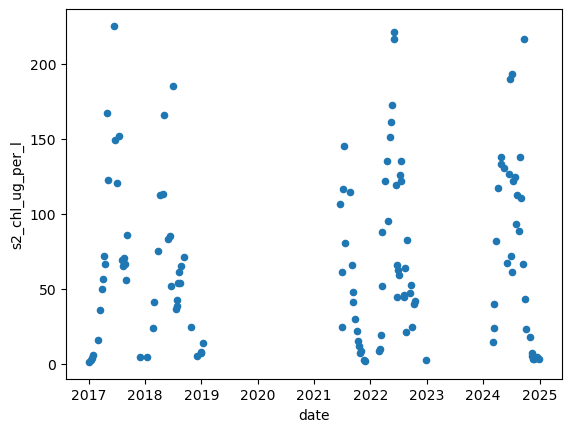

In [22]:
input_data.plot.scatter(x="date", y="s2_chl_ug_per_l")

<Axes: xlabel='date', ylabel='lstm_lswt_c'>

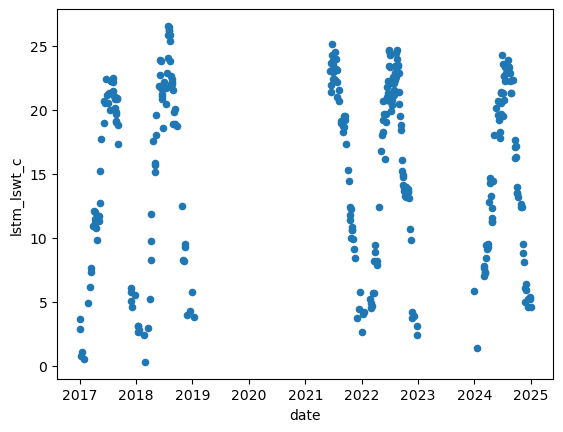

In [23]:
input_data.plot.scatter(x="date", y="lstm_lswt_c")

<Axes: xlabel='date', ylabel='chime_diatoms_ug_per_l_mean_3'>

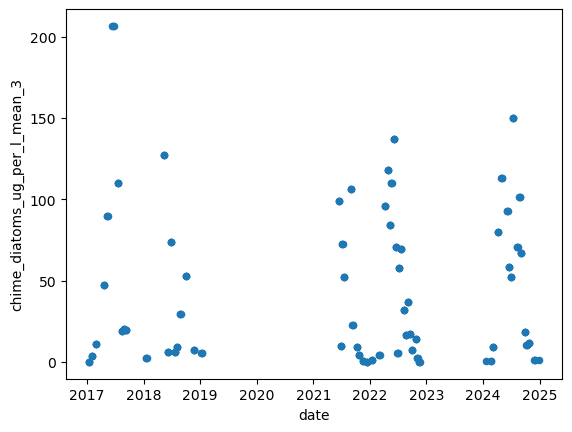

In [24]:
input_data.plot.scatter(x="date", y="chime_diatoms_ug_per_l_mean_3")